In [340]:
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

In [341]:
# Get the MNIST dataset
# Set up the data preprocessing and loading:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])  # transform the data to torch tensor and normalize
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Now let's split the training set into a training and validation set
generator = torch.Generator().manual_seed(42)  # just a random generator
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [50000, 10000], generator=generator)

print('We loaded {} training, {} validation, and {} testing samples'.format(len(train_dataset), len(val_dataset), len(test_dataset)))

# Set up the data loaders (they are iterable objects that return the data in batches)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

We loaded 50000 training, 10000 validation, and 10000 testing samples


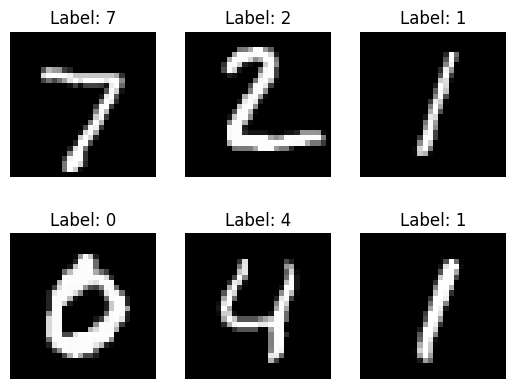

In [342]:
# Visualize some of the data 
examples = enumerate(test_loader)
batch_idx, (images, labels) = next(examples)
images = images.numpy()  # convert images to numpy for display
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i][0], cmap='gray'); plt.axis('off')
    plt.title('Label: {}'.format(labels[i]))

In [343]:
class CNNNet(nn.Module):
    def __init__(self):
        super(CNNNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  
        self.reluconv1 = nn.ReLU() 
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2) 
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) 
        self.reluconv2 = nn.ReLU() 
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)  
        self.fc1 = nn.Linear(7*7*64, 16)  
        self.relufc1 = nn.ReLU() 
        self.fc2 = nn.Linear(16, 10) 
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = self.reluconv1(self.conv1(x))
        x = self.maxpool1(x)
        x = self.reluconv2(self.conv2(x))
        x = self.maxpool2(x)
        x = x.view(-1, 7*7*64)
        x = self.relufc1(self.fc1(x))
        x = self.logsoftmax(self.fc2(x))
        return x

In [344]:
# MINE statistic networks for first convolutional layer
# I(X, T)
class MINEIn(nn.Module):
    def __init__(self):
        super(MINEIn, self).__init__()
        self.conv1 = nn.Conv2d(2, 16, kernel_size=2) 
        self.conv2 = nn.Conv2d(16, 32, kernel_size=2)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=2)
        self.elu = nn.ELU()
        self.fc1 = nn.Linear(1024, 1024)
        self.fc2 = nn.Linear(1024, 1)

    def forward(self, x, t):
        t = torch.mean(t, dim = 1, keepdim=True)
        x = torch.mean(x, dim = 1, keepdim=True)
        h = torch.cat([x, t], dim = 1)
        h = self.elu(self.conv1(h))
        h = self.elu(self.conv2(h))
        h = self.elu(self.conv3(h))
        h = h.view(-1, 1024)
        h = self.fc1(h)
        h = self.fc2(h)
        return h

# I(T, Y)
class MINEOut(nn.Module):
    def __init__(self):
        super(MINEOut, self).__init__()  
        self.conv1 = nn.Conv2d(2, 16, kernel_size=2) 
        self.conv2 = nn.Conv2d(16, 32, kernel_size=2)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=2)
        self.proj = nn.Linear(10, 28*28)
        self.elu = nn.ELU()
        self.fc1 = nn.Linear(1024, 1024)
        self.fc2 = nn.Linear(1024, 1)

    def forward(self, t, y):
        t = torch.mean(t, dim = 1, keepdim=True)
        y = self.proj(y)
        y = y.view(y.size(0), 1, 28, 28)
        h = torch.cat([t, y], dim = 1)
        h = self.elu(self.conv1(h))
        h = self.elu(self.conv2(h))
        h = self.elu(self.conv3(h))
        h = h.view(-1, 1024)
        h = self.fc1(h)
        h = self.fc2(h)
        return h

In [345]:
def smoothed_one_hot_batch(labels: torch.Tensor, epsilon: float):
    B = labels.size(0)
    num_classes = 10

    smooth = torch.full((B, num_classes), epsilon / num_classes)
    smooth[torch.arange(B), labels] = 1 - epsilon + (epsilon / num_classes)

    return smooth

In [ ]:
def donsker_varadhan_inference(joint, marginal, eps=1e-8):
    joint_mean = torch.mean(joint).detach()

    max_val = torch.max(marginal).detach()
    log_marginal_mean = max_val + torch.log(
        torch.mean(torch.exp(marginal - max_val)).detach() + eps
    ).detach()

    mi_estimator = joint_mean - log_marginal_mean

    return mi_estimator.numpy()

def donsker_varadhan_loss(joint, marginal, state={}, alpha=0.01, eps=1e-8):

    joint_mean = torch.mean(joint)

    # ---- log sum exp trick ----
    max_val = torch.max(marginal)
    exp_marg = torch.exp(marginal - max_val)
    batch_exp_mean = torch.mean(exp_marg)

    # ---- EMA(exp(T - max)) ----
    if "ema_exp" not in state:
        state["ema_exp"] = batch_exp_mean.detach()
    else:
        state["ema_exp"] = (1 - alpha) * state["ema_exp"] + alpha * batch_exp_mean.detach()

    log_sum_exp = torch.log(batch_exp_mean)

    # ---- loss de MINE ----
    loss = -(joint_mean - batch_exp_mean/(state["ema_exp"] + eps))

    # estimador MI (opcional)
    mi_est = joint_mean.detach() - torch.log(log_sum_exp).detach() - max_val.detach()

    return loss, mi_est

def train_statistic(
    statistic_in=None,
    statistic_out=None,
    model=None,
    train_loader=None,
    num_epochs=10,
    activations={},
    key=""
):
    model.eval()

    optimizer_in  = optim.Adam(statistic_in.parameters(),  lr=1e-4)
    optimizer_out = optim.Adam(statistic_out.parameters(), lr=1e-4)

    state_in = {}
    state_out = {}

    for batch_idx, (images, labels) in enumerate(train_loader):

        if batch_idx == num_epochs:
            break

        statistic_in.train()
        statistic_out.train()

        # Forward del modelo para obtener activaciones
        model(images)
        act_map = activations[key]

        # Permutación para romper la dependencia -> marginal
        perm = torch.randperm(act_map.size(0))
        act_map_perm = act_map[perm]

        # One-hot suavizado (truco para robustez)
        smoothed = smoothed_one_hot_batch(labels, 0.5)

        # ---- Joints y marginals ----
        joint_in    = statistic_in(images, act_map)
        marginal_in = statistic_in(images, act_map_perm)

        joint_out    = statistic_out(act_map, smoothed)
        marginal_out = statistic_out(act_map_perm, smoothed)

        # ---- Entrenamiento statistic_in ----
        optimizer_in.zero_grad()
        loss_in, _ = donsker_varadhan_loss(joint_in, marginal_in, state_in)
        loss_in.backward()
        optimizer_in.step()

        # ---- Entrenamiento statistic_out ----
        optimizer_out.zero_grad()
        loss_out, _ = donsker_varadhan_loss(joint_out, marginal_out, state_out)
        loss_out.backward()
        optimizer_out.step()

        # Limpiar activación para evitar usar activaciones viejas
        activations[key] = None

    return statistic_in, statistic_out


In [347]:
information_plane = {
    "conv1": {
        "in": [],
        "out": []
    }
}

In [ ]:
def compute_model_accuracy(dataloader, model):
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:  # This will iterate over the batches of the dataloader and compute the accuracy for the samples in the batch
            outputs = model(images)  # Compute the output of the model (it a bunch of scores for each potential label)
            _, predicted = torch.max(outputs.data, 1)  # Assign the predicted label as the one with the highest score
            total += labels.size(0)  # Number of samples in the batch
            correct += (predicted == labels).sum().item()  # Number of correctly classified samples in the batch
    return correct / total  # Return the accuracy 

def train_model(model=None, train_loader=None, val_loader=None, log_folder=None, num_epochs=10):
    writer = SummaryWriter(log_folder)  # create a tensorboard writer to log the training process
    criterion = nn.CrossEntropyLoss()  # define the loss function as the cross entropy loss
    optimizer = optim.SGD(model.parameters(), lr=0.01)  # define the optimizer (in this case stochastic gradient descent)

    activations = {}
    def create_hook(name):
        def hook(module, input, output):
            activations[name] = output.detach()
        return hook

    for epoch in range(num_epochs):
        model.train()  # set the model to training mode

        activations["conv1"] = None

        if epoch % 10 == 0:

            print("###########################")
            print("epoch: ", epoch)
            print("training statistics...")

            statistic_in = MINEIn()
            statistic_out = MINEOut()
            
            model.conv1.register_forward_hook(create_hook("conv1"))
            #model.conv1.register_forward_hook(create_hook("conv2"))
            
            statistic_in, statistic_out = train_statistic(statistic_in, statistic_out, model, train_loader, 1000, activations, "conv1")
            statistic_in.eval()
            statistic_out.eval()
            model.eval()

            images, labels = next(iter(train_loader))

            print("evaluating model")

            model(images)

            print("model executed")

            act_map = activations["conv1"]
            perm = torch.randperm(64).detach()
            act_map_perm = act_map[perm]

            smoothed = smoothed_one_hot_batch(labels, 0.5) # Vectorizo los labels con un pequeño ruido para que no sea tan rígido

            print("x: ", images.shape)
            print("t: ", act_map.shape)
            
            joint_in = statistic_in(images, act_map)
            marginal_in = statistic_in(images, act_map_perm)

            joint_out = statistic_out(act_map, smoothed)
            marginal_out = statistic_out(act_map_perm, smoothed)

            mi_estimator_in = donsker_varadhan_inference(joint_in, marginal_in)
            mi_estimator_out = donsker_varadhan_inference(joint_out, marginal_out)

            print("mi_estimate_in: ", mi_estimator_in)
            print("mi_estimate_out: ", mi_estimator_out)

            information_plane["conv1"]["in"].append(mi_estimator_in)
            information_plane["conv1"]["out"].append(mi_estimator_out)

            activations["conv1"] = None
            
        for batch_idx, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad()  # zero the gradients
            output = model(images)  # forward pass
            loss = criterion(output, labels)  # compute the loss
            loss.backward()  # backward pass
            optimizer.step()  # update the weights

            if batch_idx % 1000 == 0:
                writer.add_scalar('training loss', loss.item(), epoch*len(train_loader)+batch_idx)
                val_accuracy = compute_model_accuracy(val_loader, model)
                train_accuracy = compute_model_accuracy(train_loader, model)
                writer.add_scalar('validation accuracy', val_accuracy, epoch*len(train_loader)+batch_idx)
                writer.add_scalar('training accuracy', train_accuracy, epoch*len(train_loader)+batch_idx)

    return model

In [349]:
cnnmodel = CNNNet()
cnnmodel = train_model(model=cnnmodel, train_loader=train_loader, val_loader=val_loader, log_folder="torchlogs/cnnnet", num_epochs=100)

###########################
epoch:  0
training statistics...
evaluating model
model executed
x:  torch.Size([64, 1, 28, 28])
t:  torch.Size([64, 32, 28, 28])
mi_estimate_in:  1.2377277e-06
mi_estimate_out:  8.719042e-06
###########################
epoch:  10
training statistics...
evaluating model
model executed
x:  torch.Size([64, 1, 28, 28])
t:  torch.Size([64, 32, 28, 28])
mi_estimate_in:  -9.872019e-07
mi_estimate_out:  5.291775e-06
###########################
epoch:  20
training statistics...
evaluating model
model executed
x:  torch.Size([64, 1, 28, 28])
t:  torch.Size([64, 32, 28, 28])
mi_estimate_in:  -4.272908e-06
mi_estimate_out:  -1.3964251e-05
###########################
epoch:  30
training statistics...
evaluating model
model executed
x:  torch.Size([64, 1, 28, 28])
t:  torch.Size([64, 32, 28, 28])
mi_estimate_in:  1.0666903e-05
mi_estimate_out:  1.2714416e-05
###########################
epoch:  40
training statistics...
evaluating model
model executed
x:  torch.Size([64, 

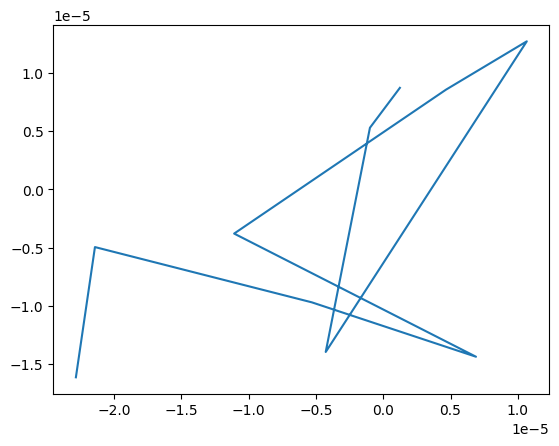

In [350]:
plt.plot(information_plane["conv1"]["in"], information_plane["conv1"]["out"])
plt.show()